In [23]:
#importing necessary libraries for data exploration and preprocessing
import os
import numpy as np
import tensorflow as tf
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

In [ ]:
#Paths
RAW_DIR = Path("../data/raw/asl_alphabet")
PROCESSED_DIR = Path("../data/processed/asl_64") 
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
#Resizing images to a consistent size for model input
IMAGE_SIZE = (64, 64)  
SEED = 42

print("RAW_DIR exists:", RAW_DIR.exists())
print("Number of class folders:", len([p for p in RAW_DIR.iterdir() if p.is_dir()]))

RAW_DIR exists: True
Number of class folders: 36


In [ ]:
#Creating label mappings for classes
classes = sorted([p.name for p in RAW_DIR.iterdir() if p.is_dir()])
label_to_id = {c:i for i, c in enumerate(classes)}
id_to_label = {i:c for c, i in label_to_id.items()}

print("Classes:", classes)
print("Total classes:", len(classes))


Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Total classes: 36


In [ ]:
#Building a metadata DataFrame with image paths and labels
rows = []
for c in classes:
    folder = RAW_DIR / c
    for img_name in os.listdir(folder):
        img_path = folder / img_name
        if img_path.is_file():
            rows.append({"path": str(img_path), "label": c, "label_id": label_to_id[c]})

meta_df = pd.DataFrame(rows)
print("Total images:", len(meta_df))
meta_df.head()


Total images: 142261


,path,label,label_id
0,..\data\raw\asl_alphabet\0\1 copy.jpg,0,0
1,..\data\raw\asl_alphabet\0\1.jpg,0,0
2,..\data\raw\asl_alphabet\0\10 copy.jpg,0,0
3,..\data\raw\asl_alphabet\0\10.jpg,0,0
4,..\data\raw\asl_alphabet\0\100 copy.jpg,0,0


In [11]:
#Class distribution
class_counts = meta_df["label"].value_counts().sort_index()
class_counts.head(15), class_counts.tail(15)

(label
 0    3070
 1    1570
 2    1570
 3    1570
 4    3070
 5    3070
 6    3070
 7    3070
 8    3070
 9    3070
 a    6070
 b    6070
 c    6070
 d    6070
 e    3070
 Name: count, dtype: int64,
 label
 l    6494
 m    2924
 n    3968
 o    7294
 p    2566
 q    3590
 r    3538
 s    2374
 t    3076
 u    3244
 v    3926
 w    2086
 x    2330
 y    2454
 z    2218
 Name: count, dtype: int64)

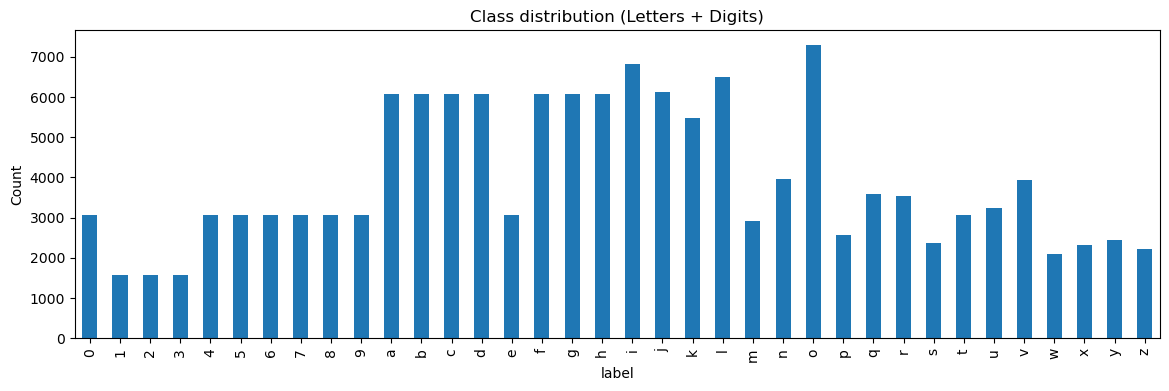

In [13]:
#Visualizing class distribution
plt.figure(figsize=(14,4))
class_counts.plot(kind="bar")
plt.title("Class distribution (Letters + Digits)")
plt.ylabel("Count")
plt.show()

In [15]:
#Splitting the dataset into train, validation, and test sets (70/15/15) with stratification
train_df, temp_df = train_test_split(meta_df,test_size=0.30, stratify=meta_df["label_id"],random_state=SEED) 
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=SEED)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 99582 Val: 21339 Test: 21340


In [32]:
#Standardising size and creating TensorFlow datasets
IMAGE_SIZE = (64, 64)   
BATCH_SIZE = 32

In [ ]:
#Creating TensorFlow datasets
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)         # grayscale
    img = tf.image.resize(img, IMAGE_SIZE)              # standardize size
    img = tf.cast(img, tf.float32) / 255.0              # normalize 0-1
    return img, label

def make_dataset(df, shuffle=True):
    paths = df["path"].values
    labels = df["label_id"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)

print("Datasets created ")


Datasets created 


Batch images shape: (32, 64, 64, 1)
Batch labels shape: (32,)


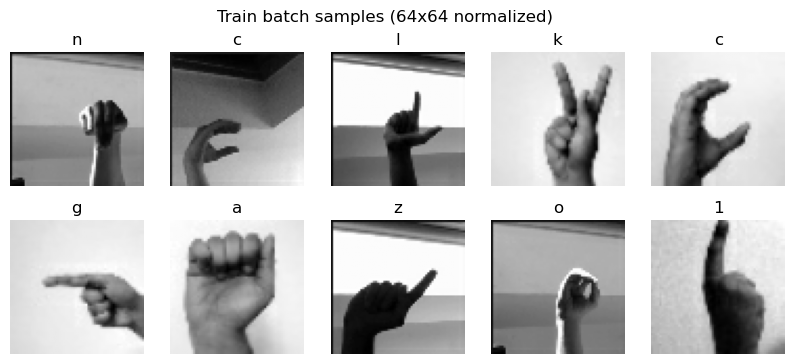

In [30]:

#Checking a batch from the training dataset
for images, labels in train_ds.take(1):
    print("Batch images shape:", images.shape)   # (32, 64, 64, 1)
    print("Batch labels shape:", labels.shape)   # (32,)
    
    plt.figure(figsize=(10,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(id_to_label[int(labels[i])])
        plt.axis("off")
    plt.suptitle("Train batch samples (64x64 normalized)")
    plt.show()


In [ ]:
#Saving the split CSVs for future reference
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

train_df.to_csv(PROCESSED_DIR / "train_split.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val_split.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test_split.csv", index=False)

print("Split CSVs saved to data/processed ")


Split CSVs saved to data/processed 
